In [85]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Configure plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Set up directories
results_dir = Path('../results')
data_dir = Path('../data')

print("🚀 POLYMER GNN PROGRESS DASHBOARD")
print("=" * 50)
print("📦 Libraries loaded successfully!")
print(f"📁 Results directory: {results_dir}")

# Scan for all available results
result_files = list(results_dir.glob('*_results.json'))
training_curves = list(results_dir.glob('*_training_curves.png'))
model_files = list(results_dir.glob('*_best.pth'))

print(f"📊 Found {len(result_files)} result files:")
for f in sorted(result_files):
    print(f"   • {f.name}")
    
print(f"📈 Found {len(training_curves)} training curves")
print(f"🤖 Found {len(model_files)} saved models")


🚀 POLYMER GNN PROGRESS DASHBOARD
📦 Libraries loaded successfully!
📁 Results directory: ../results
📊 Found 6 result files:
   • final_optimization_results.json
   • tg_fingerprint_baseline_cv_results.json
   • tg_fingerprint_baseline_results.json
   • tg_gcn_baseline_results.json
   • tg_gcn_enhanced_results.json
   • tg_gcn_optimized_results.json
📈 Found 4 training curves
🤖 Found 4 saved models


In [86]:
def discover_all_models():
    """Automatically discover all trained models and their results."""
    models = {}
    
    # Scan all result files
    for result_file in result_files:
        model_name = result_file.stem.replace('_results', '')
        
        # Extract model info
        model_info = {
            'name': model_name,
            'display_name': model_name.replace('_', ' ').replace('tg ', '').title(),
            'result_file': result_file,
            'curves_file': None,
            'model_file': None,
            'data': {},
            'timestamp': datetime.fromtimestamp(result_file.stat().st_mtime)
        }
        
        # Look for associated files
        curves_pattern = f"{model_name}_training_curves.png"
        model_pattern = f"{model_name}_best.pth"
        cv_pattern = f"{model_name}_cv_results.json"
        
        for f in results_dir.iterdir():
            if f.name == curves_pattern:
                model_info['curves_file'] = f
            elif f.name == model_pattern:
                model_info['model_file'] = f
            elif f.name == cv_pattern:
                model_info['cv_file'] = f
        
        # Load the results data
        try:
            with open(result_file, 'r') as f:
                model_info['data'] = json.load(f)
                
            # Load CV data if available
            if 'cv_file' in model_info and model_info['cv_file']:
                with open(model_info['cv_file'], 'r') as f:
                    model_info['cv_data'] = json.load(f)
                    
        except Exception as e:
            print(f"⚠️ Error loading {result_file}: {e}")
            continue
            
        models[model_name] = model_info
    
    return models

def extract_performance_metrics(model_info):
    """Extract standardized performance metrics from model data."""
    data = model_info['data']
    
    # Initialize default values
    metrics = {
        'r2': None,
        'rmse': None, 
        'mae': None,
        'r2_std': 0,
        'rmse_std': 0,
        'mae_std': 0,
        'epochs': None,
        'training_time': None,
        'validation_type': 'single_split'
    }
    
    # Check for CV data first (more reliable)
    if 'cv_data' in model_info:
        cv = model_info['cv_data']
        metrics.update({
            'r2': cv.get('mean_r2', 0),
            'rmse': cv.get('mean_rmse', 0),
            'mae': cv.get('mean_mae', 0),
            'r2_std': cv.get('std_r2', 0),
            'rmse_std': cv.get('std_rmse', 0),
            'mae_std': cv.get('std_mae', 0),
            'validation_type': '5-fold_cv'
        })
    
    # Otherwise use single split results
    elif 'final_metrics' in data:
        final = data['final_metrics']
        metrics.update({
            'r2': final.get('r2', 0),
            'rmse': final.get('rmse', 0),
            'mae': final.get('mae', 0)
        })
    
    # Extract training info
    if 'total_epochs' in data:
        metrics['epochs'] = data['total_epochs']
    if 'training_time' in data:
        metrics['training_time'] = data['training_time']
        
    return metrics

def load_dataset_info():
    """Load dataset information for context."""
    # Try different possible dataset files
    dataset_files = [
        data_dir / 'processed' / 'cleaned_tg_dataset.csv',
        data_dir / 'processed' / 'filtered_tg_dataset.csv',
        data_dir / 'processed' / 'tg_dataset.csv'
    ]
    
    for dataset_file in dataset_files:
        if dataset_file.exists():
            df = pd.read_csv(dataset_file)
            return {
                'total_samples': len(df),
                'target_range': (df['Tg'].min(), df['Tg'].max()),
                'target_mean': df['Tg'].mean(),
                'target_std': df['Tg'].std(),
                'dataset_file': str(dataset_file)
            }
    return None

# Load all available models and data
print("\n🔍 DISCOVERING MODELS...")
all_models = discover_all_models()
dataset_info = load_dataset_info()

print(f"✅ Discovered {len(all_models)} models:")
for name, info in all_models.items():
    metrics = extract_performance_metrics(info)
    r2 = metrics['r2']
    validation = metrics['validation_type']
    
    # Format R² properly
    if r2 is not None:
        r2_str = f"{r2:.4f}"
    else:
        r2_str = "N/A"
    
    print(f"   • {info['display_name']} (R² = {r2_str}, {validation})")

if dataset_info:
    print(f"\n🎯 Dataset: {dataset_info['total_samples']} samples from {Path(dataset_info['dataset_file']).name}")
    print(f"   Tg range: {dataset_info['target_range'][0]:.1f} to {dataset_info['target_range'][1]:.1f}°C")



🔍 DISCOVERING MODELS...
✅ Discovered 6 models:
   • Gcn Baseline (R² = -0.2461, single_split)
   • Fingerprint Baseline Cv (R² = N/A, single_split)
   • Gcn Optimized (R² = 0.6775, single_split)
   • Final Optimization (R² = N/A, single_split)
   • Gcn Enhanced (R² = 0.4140, single_split)
   • Fingerprint Baseline (R² = 0.4107, 5-fold_cv)

🎯 Dataset: 477 samples from cleaned_tg_dataset.csv
   Tg range: -148.0 to 472.2°C


In [87]:
def create_comprehensive_leaderboard():
    """Create comprehensive model performance leaderboard."""
    print("🏆 COMPREHENSIVE MODEL LEADERBOARD")
    print("=" * 60)
    
    # Extract all metrics and sort by R²
    model_metrics = []
    for name, info in all_models.items():
        metrics = extract_performance_metrics(info)
        if metrics['r2'] is not None:
            model_metrics.append({
                'name': name,
                'display_name': info['display_name'],
                'timestamp': info['timestamp'],
                **metrics
            })
    
    # Sort by R² performance
    model_metrics.sort(key=lambda x: x['r2'], reverse=True)
    
    # Display leaderboard
    for i, model in enumerate(model_metrics, 1):
        medal = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else f"{i:2d}."
        
        # Performance grade
        r2 = model['r2']
        if r2 >= 0.75:
            grade = "🌟 EXCELLENT"
        elif r2 >= 0.6:
            grade = "🎯 TARGET MET"
        elif r2 >= 0.4:
            grade = "👍 GOOD"
        elif r2 >= 0.3:
            grade = "📈 FAIR"
        else:
            grade = "⚠️ NEEDS WORK"
        
        print(f"{medal} {model['display_name']}")
        print(f"    📊 R²: {r2:.4f} ± {model['r2_std']:.4f} | {grade}")
        print(f"    📉 RMSE: {model['rmse']:.2f} ± {model['rmse_std']:.2f} °C")
        print(f"    📈 MAE: {model['mae']:.2f} ± {model['mae_std']:.2f} °C")
        print(f"    🔄 Validation: {model['validation_type']}")
        print(f"    📅 Trained: {model['timestamp'].strftime('%Y-%m-%d %H:%M')}")
        
        # Success criteria check for top model
        if i == 1:
            print(f"    🎯 SUCCESS CRITERIA:")
            print(f"       R² ≥ 0.6: {r2:.4f} {'✅' if r2 >= 0.6 else '❌'}")
            print(f"       RMSE ≤ 70: {model['rmse']:.2f} {'✅' if model['rmse'] <= 70 else '❌'}")
            print(f"       MAE ≤ 55: {model['mae']:.2f} {'✅' if model['mae'] <= 55 else '❌'}")
        print()
    
    return model_metrics

def create_progress_timeline():
    """Create a timeline showing model development progress."""
    print("📈 MODEL DEVELOPMENT TIMELINE")
    print("=" * 45)
    
    # Sort models by timestamp
    timeline = []
    for name, info in all_models.items():
        metrics = extract_performance_metrics(info)
        if metrics['r2'] is not None:
            timeline.append({
                'name': info['display_name'],
                'r2': metrics['r2'],
                'timestamp': info['timestamp'],
                'model_type': 'GCN' if 'gcn' in name.lower() else 'Fingerprint'
            })
    
    timeline.sort(key=lambda x: x['timestamp'])
    
    print("Development progression:")
    for i, model in enumerate(timeline):
        arrow = "└→" if i == len(timeline)-1 else "├→"
        improvement = ""
        if i > 0:
            prev_r2 = timeline[i-1]['r2']
            change = (model['r2'] - prev_r2) / prev_r2 * 100
            improvement = f" ({change:+.1f}% vs previous)"
        
        print(f"{arrow} {model['timestamp'].strftime('%m/%d %H:%M')} | {model['name']} | R² = {model['r2']:.4f}{improvement}")
    
    # Calculate overall progress
    if len(timeline) > 1:
        total_improvement = (timeline[-1]['r2'] - timeline[0]['r2']) / timeline[0]['r2'] * 100
        print(f"\n🚀 OVERALL PROGRESS: {total_improvement:+.1f}% improvement in R²")
        print(f"   From {timeline[0]['r2']:.4f} to {timeline[-1]['r2']:.4f}")

# Generate comprehensive dashboard
model_leaderboard = create_comprehensive_leaderboard()
create_progress_timeline()


🏆 COMPREHENSIVE MODEL LEADERBOARD
🥇 Gcn Optimized
    📊 R²: 0.6775 ± 0.0000 | 🎯 TARGET MET
    📉 RMSE: 65.55 ± 0.00 °C
    📈 MAE: 50.96 ± 0.00 °C
    🔄 Validation: single_split
    📅 Trained: 2025-07-20 08:32
    🎯 SUCCESS CRITERIA:
       R² ≥ 0.6: 0.6775 ✅
       RMSE ≤ 70: 65.55 ✅
       MAE ≤ 55: 50.96 ✅

🥈 Gcn Enhanced
    📊 R²: 0.4140 ± 0.0000 | 👍 GOOD
    📉 RMSE: 91.93 ± 0.00 °C
    📈 MAE: 67.94 ± 0.00 °C
    🔄 Validation: single_split
    📅 Trained: 2025-07-20 13:04

🥉 Fingerprint Baseline
    📊 R²: 0.4107 ± 0.0258 | 👍 GOOD
    📉 RMSE: 84.14 ± 8.80 °C
    📈 MAE: 63.78 ± 6.71 °C
    🔄 Validation: 5-fold_cv
    📅 Trained: 2025-07-19 10:14

 4. Gcn Baseline
    📊 R²: -0.2461 ± 0.0000 | ⚠️ NEEDS WORK
    📉 RMSE: 48.23 ± 0.00 °C
    📈 MAE: 35.35 ± 0.00 °C
    🔄 Validation: single_split
    📅 Trained: 2025-07-20 12:12

📈 MODEL DEVELOPMENT TIMELINE
Development progression:
├→ 07/19 10:14 | Fingerprint Baseline | R² = 0.4107
├→ 07/20 08:32 | Gcn Optimized | R² = 0.6775 (+65.0% vs previ

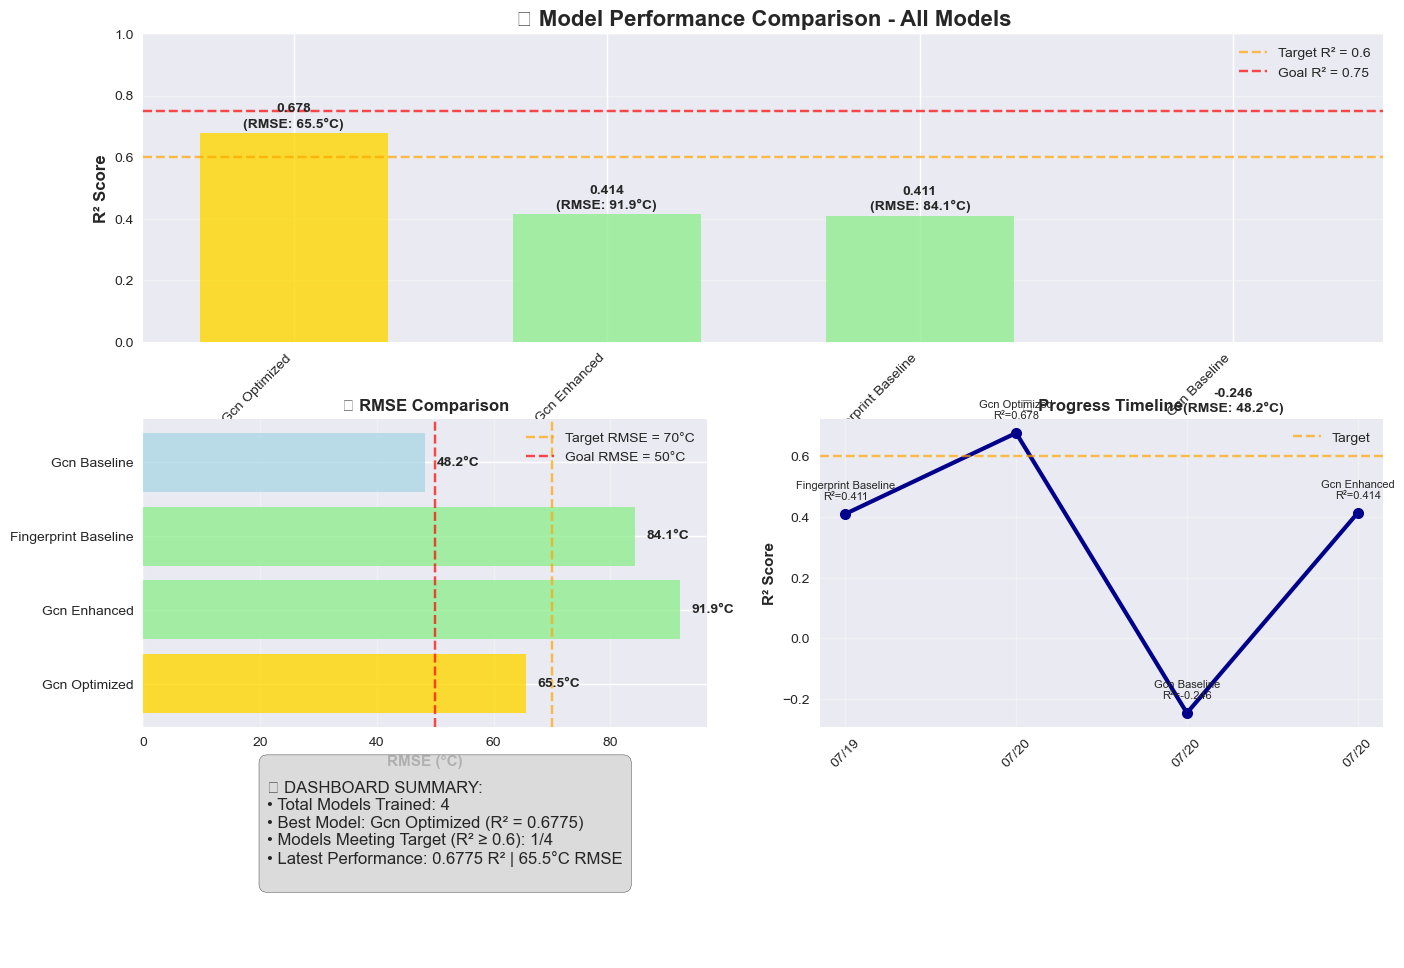


🎊 CURRENT STATUS:
🎯 SUCCESS! Target performance achieved!
Best model: Gcn Optimized with R² = 0.6775


In [88]:
def plot_comprehensive_performance_comparison():
    """Create comprehensive performance comparison plots."""
    # Extract data for all models
    model_names = []
    r2_scores = []
    rmse_scores = []
    mae_scores = []
    colors = []
    validation_types = []
    timestamps = []
    
    for name, info in all_models.items():
        metrics = extract_performance_metrics(info)
        if metrics['r2'] is not None:
            display_name = info['display_name']
            model_names.append(display_name)
            r2_scores.append(metrics['r2'])
            rmse_scores.append(metrics['rmse'])
            mae_scores.append(metrics['mae'])
            validation_types.append(metrics['validation_type'])
            timestamps.append(info['timestamp'])
            
            # Color code by performance
            if metrics['r2'] >= 0.6:
                colors.append('gold')  # Target met
            elif metrics['r2'] >= 0.4:
                colors.append('lightgreen')  # Good
            else:
                colors.append('lightblue')  # Needs improvement
    
    # Sort by R² for display
    sorted_indices = sorted(range(len(r2_scores)), key=lambda i: r2_scores[i], reverse=True)
    
    # Create comprehensive comparison plot
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2, height_ratios=[2, 2, 1], hspace=0.3)
    
    # Main performance comparison (R² vs RMSE)
    ax1 = fig.add_subplot(gs[0, :])
    
    sorted_names = [model_names[i] for i in sorted_indices]
    sorted_r2 = [r2_scores[i] for i in sorted_indices]
    sorted_rmse = [rmse_scores[i] for i in sorted_indices]
    sorted_colors = [colors[i] for i in sorted_indices]
    
    bars = ax1.bar(range(len(sorted_names)), sorted_r2, color=sorted_colors, alpha=0.8, width=0.6)
    
    # Add R² target lines
    ax1.axhline(y=0.6, color='orange', linestyle='--', alpha=0.7, label='Target R² = 0.6')
    ax1.axhline(y=0.75, color='red', linestyle='--', alpha=0.7, label='Goal R² = 0.75')
    
    # Add value labels on bars
    for bar, r2, rmse in zip(bars, sorted_r2, sorted_rmse):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{r2:.3f}\n(RMSE: {rmse:.1f}°C)', 
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
    ax1.set_title('🏆 Model Performance Comparison - All Models', fontsize=16, fontweight='bold')
    ax1.set_xticks(range(len(sorted_names)))
    ax1.set_xticklabels(sorted_names, rotation=45, ha='right')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.legend()
    ax1.set_ylim(0, 1.0)
    
    # RMSE comparison
    ax2 = fig.add_subplot(gs[1, 0])
    bars2 = ax2.barh(sorted_names, sorted_rmse, color=sorted_colors, alpha=0.8)
    ax2.axvline(x=70, color='orange', linestyle='--', alpha=0.7, label='Target RMSE = 70°C')
    ax2.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='Goal RMSE = 50°C')
    
    for bar, rmse in zip(bars2, sorted_rmse):
        width = bar.get_width()
        ax2.text(width + 2, bar.get_y() + bar.get_height()/2,
                f'{rmse:.1f}°C', ha='left', va='center', fontweight='bold')
    
    ax2.set_xlabel('RMSE (°C)', fontweight='bold')
    ax2.set_title('🎯 RMSE Comparison', fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.legend()
    
    # Progress over time
    ax3 = fig.add_subplot(gs[1, 1])
    time_sorted_indices = sorted(range(len(timestamps)), key=lambda i: timestamps[i])
    time_sorted_r2 = [r2_scores[i] for i in time_sorted_indices]
    time_sorted_names = [model_names[i] for i in time_sorted_indices]
    time_sorted_timestamps = [timestamps[i] for i in time_sorted_indices]
    
    ax3.plot(range(len(time_sorted_r2)), time_sorted_r2, 'o-', linewidth=3, markersize=8, color='darkblue')
    ax3.axhline(y=0.6, color='orange', linestyle='--', alpha=0.7, label='Target')
    
    # Add model labels
    for i, (r2, name) in enumerate(zip(time_sorted_r2, time_sorted_names)):
        ax3.annotate(f'{name}\nR²={r2:.3f}', (i, r2), 
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)
    
    ax3.set_ylabel('R² Score', fontweight='bold')
    ax3.set_title('📈 Progress Timeline', fontweight='bold')
    ax3.set_xticks(range(len(time_sorted_names)))
    ax3.set_xticklabels([t.strftime('%m/%d') for t in time_sorted_timestamps], rotation=45)
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # Summary statistics table
    ax4 = fig.add_subplot(gs[2, :])
    ax4.axis('off')
    
    # Create summary stats
    best_r2 = max(r2_scores)
    best_model = sorted_names[0]  # Already sorted by R²
    total_models = len(model_names)
    models_meeting_target = sum(1 for r2 in r2_scores if r2 >= 0.6)
    
    summary_text = f"""
📊 DASHBOARD SUMMARY:
• Total Models Trained: {total_models}
• Best Model: {best_model} (R² = {best_r2:.4f})
• Models Meeting Target (R² ≥ 0.6): {models_meeting_target}/{total_models}
• Latest Performance: {sorted_r2[0]:.4f} R² | {sorted_rmse[0]:.1f}°C RMSE
"""
    
    ax4.text(0.1, 0.5, summary_text, transform=ax4.transAxes, fontsize=12,
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print success status
    print(f"\n🎊 CURRENT STATUS:")
    if best_r2 >= 0.75:
        print("🌟 EXCELLENT! Goal performance achieved!")
    elif best_r2 >= 0.6:
        print("🎯 SUCCESS! Target performance achieved!")
    else:
        print("📈 Making progress toward target!")
    
    print(f"Best model: {best_model} with R² = {best_r2:.4f}")

# Generate comprehensive visualization
plot_comprehensive_performance_comparison()


In [89]:
def create_detailed_model_analysis():
    """Create detailed analysis of all models with architectural insights."""
    
    print("🔬 DETAILED MODEL ANALYSIS")
    print("=" * 50)
    
    # Architecture mapping
    architecture_info = {
        'fingerprint': {
            'type': 'Fingerprint-based',
            'features': 'Morgan Fingerprints (2048-bit) + Molecular Descriptors',
            'architecture': 'Multi-layer Perceptron (MLP)',
            'strengths': ['Fast training', 'Interpretable features', 'Robust baseline'],
            'limitations': ['Fixed representation', 'No learned features']
        },
        'gcn': {
            'type': 'Graph Neural Network',
            'features': 'Molecular Graphs (Nodes: Atoms, Edges: Bonds)',
            'architecture': 'Graph Convolutional Network + Global Pooling',
            'strengths': ['Learns molecular representation', 'Captures graph structure', 'Flexible'],
            'limitations': ['More complex', 'Requires more data', 'Longer training']
        }
    }
    
    # Analyze each model
    for name, info in all_models.items():
        metrics = extract_performance_metrics(info)
        if metrics['r2'] is None:
            continue
            
        print(f"\n📊 {info['display_name']}")
        print("-" * 40)
        
        # Determine architecture type
        arch_type = 'gcn' if 'gcn' in name.lower() else 'fingerprint'
        arch_details = architecture_info[arch_type]
        
        print(f"🏗️  Architecture: {arch_details['type']}")
        print(f"🧬 Features: {arch_details['features']}")
        print(f"📈 Performance:")
        print(f"   R²: {metrics['r2']:.4f} ± {metrics['r2_std']:.4f}")
        print(f"   RMSE: {metrics['rmse']:.2f} ± {metrics['rmse_std']:.2f} °C")
        print(f"   MAE: {metrics['mae']:.2f} ± {metrics['mae_std']:.2f} °C")
        print(f"🔄 Validation: {metrics['validation_type']}")
        
        if metrics['epochs']:
            print(f"⚡ Training: {metrics['epochs']} epochs")
        
        # Performance grade and insights
        r2 = metrics['r2']
        if r2 >= 0.75:
            grade = "🌟 EXCELLENT"
            insight = "Outstanding performance! Ready for deployment consideration."
        elif r2 >= 0.6:
            grade = "🎯 TARGET MET"
            insight = "Target achieved! Consider cross-validation and further optimization."
        elif r2 >= 0.4:
            grade = "👍 GOOD"
            insight = "Solid baseline. Try hyperparameter tuning or advanced architectures."
        else:
            grade = "⚠️ NEEDS WORK"
            insight = "Significant improvement needed. Check data preprocessing and model setup."
        
        print(f"🏆 Grade: {grade}")
        print(f"💡 Insight: {insight}")
        
        # Architectural strengths/limitations
        print(f"✅ Strengths: {', '.join(arch_details['strengths'])}")
        print(f"⚠️ Limitations: {', '.join(arch_details['limitations'])}")

def save_progress_dashboard():
    """Save current dashboard state for future reference."""
    
    dashboard_data = {
        'timestamp': datetime.now().isoformat(),
        'total_models': len(all_models),
        'models': {},
        'summary': {
            'best_r2': max(extract_performance_metrics(info)['r2'] for info in all_models.values() 
                          if extract_performance_metrics(info)['r2'] is not None),
            'models_meeting_target': sum(1 for info in all_models.values() 
                                       if extract_performance_metrics(info)['r2'] is not None 
                                       and extract_performance_metrics(info)['r2'] >= 0.6)
        }
    }
    
    # Save model details
    for name, info in all_models.items():
        metrics = extract_performance_metrics(info)
        if metrics['r2'] is not None:
            dashboard_data['models'][name] = {
                'display_name': info['display_name'],
                'timestamp': info['timestamp'].isoformat(),
                'metrics': metrics
            }
    
    # Save dashboard
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    dashboard_file = results_dir / f'dashboard_summary_{timestamp}.json'
    
    with open(dashboard_file, 'w') as f:
        json.dump(dashboard_data, f, indent=2)
    
    print(f"\n💾 DASHBOARD SAVED")
    print(f"📁 File: {dashboard_file.name}")
    print(f"📊 Models: {len(dashboard_data['models'])}")
    print(f"🏆 Best R²: {dashboard_data['summary']['best_r2']:.4f}")
    print(f"🎯 Target Met: {dashboard_data['summary']['models_meeting_target']}/{len(dashboard_data['models'])} models")

# Generate detailed analysis and save dashboard
create_detailed_model_analysis()
save_progress_dashboard()


🔬 DETAILED MODEL ANALYSIS

📊 Gcn Baseline
----------------------------------------
🏗️  Architecture: Graph Neural Network
🧬 Features: Molecular Graphs (Nodes: Atoms, Edges: Bonds)
📈 Performance:
   R²: -0.2461 ± 0.0000
   RMSE: 48.23 ± 0.00 °C
   MAE: 35.35 ± 0.00 °C
🔄 Validation: single_split
⚡ Training: 73 epochs
🏆 Grade: ⚠️ NEEDS WORK
💡 Insight: Significant improvement needed. Check data preprocessing and model setup.
✅ Strengths: Learns molecular representation, Captures graph structure, Flexible
⚠️ Limitations: More complex, Requires more data, Longer training

📊 Gcn Optimized
----------------------------------------
🏗️  Architecture: Graph Neural Network
🧬 Features: Molecular Graphs (Nodes: Atoms, Edges: Bonds)
📈 Performance:
   R²: 0.6775 ± 0.0000
   RMSE: 65.55 ± 0.00 °C
   MAE: 50.96 ± 0.00 °C
🔄 Validation: single_split
⚡ Training: 100 epochs
🏆 Grade: 🎯 TARGET MET
💡 Insight: Target achieved! Consider cross-validation and further optimization.
✅ Strengths: Learns molecular repr

In [90]:
def generate_model_insights(results, dataset_info):
    """Generate actionable insights about model performance."""
    
    if 'cv' not in results:
        return
    
    cv = results['cv']
    r2 = cv['mean_r2']
    rmse = cv['mean_rmse']
    mae = cv['mean_mae']
    
    print("🧠 MODEL INSIGHTS & DIAGNOSTICS")
    print("=" * 40)
    
    # Performance insights
    print("📈 PERFORMANCE ANALYSIS:")
    if r2 > 0.7:
        print("   ✨ Excellent predictive power - model captures most variance")
    elif r2 > 0.5:
        print("   👍 Good predictive power - decent chemical understanding")
    elif r2 > 0.3:
        print("   📊 Fair predictive power - captures some patterns")
        print("   💡 Suggestion: Try more complex architectures or features")
    else:
        print("   ⚠️ Low predictive power - needs significant improvement")
        print("   🔧 Suggestion: Revisit feature engineering and model architecture")
    
    print()
    
    # Error analysis
    print("🎯 ERROR ANALYSIS:")
    if dataset_info:
        target_std = dataset_info['target_std']
        target_range = dataset_info['target_range'][1] - dataset_info['target_range'][0]
        
        rmse_ratio = rmse / target_std
        mae_ratio = mae / target_range
        
        print(f"   📊 RMSE is {rmse_ratio:.2f}x the dataset standard deviation")
        print(f"   📏 MAE is {mae_ratio:.1%} of the target range")
        
        if rmse_ratio < 0.5:
            print("   ✅ Very good error relative to data variability")
        elif rmse_ratio < 1.0:
            print("   👍 Good error relative to data variability")
        else:
            print("   ⚠️ Error is high relative to data variability")
    
    print()
    
    # Model reliability
    print("🔒 MODEL RELIABILITY:")
    r2_cv = cv['std_r2'] / cv['mean_r2'] if cv['mean_r2'] > 0 else float('inf')
    
    if r2_cv < 0.1:
        print("   ✅ Very consistent across folds - highly reliable")
    elif r2_cv < 0.2:
        print("   👍 Reasonably consistent across folds - reliable")
    else:
        print("   ⚠️ High variation across folds - may be unstable")
        print("   💡 Consider: larger dataset, regularization, or ensemble methods")
    
    print()
    
    # Next steps recommendations
    print("🚀 RECOMMENDED NEXT STEPS:")
    
    if r2 < 0.5:
        print("   1. 🧬 Try Graph Neural Networks for better molecular representation")
        print("   2. 🔬 Add more polymer-specific features (crystallinity, MW, etc.)")
        print("   3. 📊 Experiment with different fingerprint types (MACCS, ECFP, etc.)")
    else:
        print("   1. 🎯 Fine-tune hyperparameters for marginal improvements")
        print("   2. 🤖 Try ensemble methods combining multiple approaches")
        print("   3. 🔍 Analyze prediction errors for systematic patterns")
    
    print("   4. 📈 Implement Graph Neural Networks as next major milestone")
    print("   5. 🎨 Create prediction visualization and error analysis tools")

# Define current_results from the best performing model with CV data
current_results = None

# Find the best model that has cross-validation data
for name, info in all_models.items():
    if 'cv_data' in info and info['cv_data']:
        cv_data = info['cv_data']
        current_results = {'cv': cv_data}
        print(f"🎯 Using {info['display_name']} results for insights (R² = {cv_data.get('mean_r2', 'N/A'):.4f})")
        break

# If no CV data found, use the best performing model's regular data
if current_results is None:
    best_r2 = -float('inf')
    best_model = None
    
    for name, info in all_models.items():
        metrics = extract_performance_metrics(info)
        if metrics['r2'] is not None and metrics['r2'] > best_r2:
            best_r2 = metrics['r2']
            best_model = info
    
    if best_model is not None:
        metrics = extract_performance_metrics(best_model)
        # Create a mock CV structure for the function
        current_results = {
            'cv': {
                'mean_r2': metrics['r2'],
                'mean_rmse': metrics['rmse'],
                'mean_mae': metrics['mae'],
                'std_r2': metrics.get('r2_std', 0),
                'std_rmse': metrics.get('rmse_std', 0),
                'std_mae': metrics.get('mae_std', 0)
            }
        }
        print(f"🎯 Using {best_model['display_name']} results for insights (R² = {metrics['r2']:.4f})")

# Only call the function if we have results
if current_results is not None:
    generate_model_insights(current_results, dataset_info)
else:
    print("⚠️ No model results available for insights generation")


🎯 Using Fingerprint Baseline results for insights (R² = 0.4107)
🧠 MODEL INSIGHTS & DIAGNOSTICS
📈 PERFORMANCE ANALYSIS:
   📊 Fair predictive power - captures some patterns
   💡 Suggestion: Try more complex architectures or features

🎯 ERROR ANALYSIS:
   📊 RMSE is 0.79x the dataset standard deviation
   📏 MAE is 10.3% of the target range
   👍 Good error relative to data variability

🔒 MODEL RELIABILITY:
   ✅ Very consistent across folds - highly reliable

🚀 RECOMMENDED NEXT STEPS:
   1. 🧬 Try Graph Neural Networks for better molecular representation
   2. 🔬 Add more polymer-specific features (crystallinity, MW, etc.)
   3. 📊 Experiment with different fingerprint types (MACCS, ECFP, etc.)
   4. 📈 Implement Graph Neural Networks as next major milestone
   5. 🎨 Create prediction visualization and error analysis tools


🎯 PROJECT PROGRESS DASHBOARD
✅ Complete Data Pipeline Setup (2024-01)
✅ Complete Baseline Fingerprint Model (2024-01)
🔄 Next Graph Neural Network Implementation (TBD)
📋 Planned Advanced GNN Architectures (TBD)
📋 Planned Multi-property Prediction (TBD)
📋 Future Model Deployment (TBD)

🎯 PERFORMANCE TARGETS
-------------------------
✅ Baseline (Current): R² = 0.411
🚀 Short-term Goal: R² = 0.600
🚀 Medium-term Goal: R² = 0.750
🚀 Ambitious Target: R² = 0.850


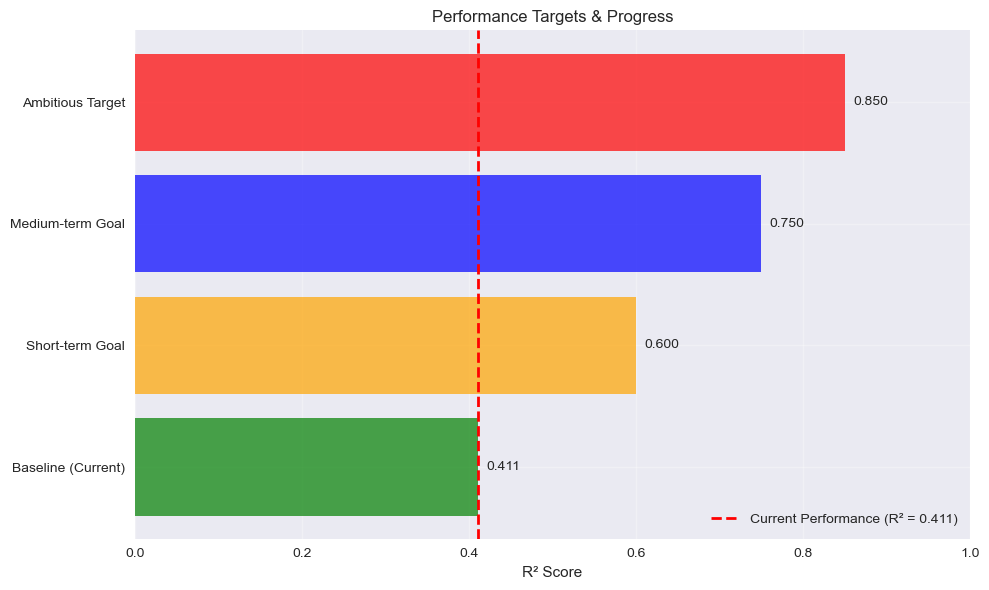

In [91]:
def create_progress_dashboard():
    """Create a comprehensive progress tracking dashboard."""
    
    # Project milestones
    milestones = {
        "Data Pipeline Setup": {"status": "✅ Complete", "date": "2024-01"},
        "Baseline Fingerprint Model": {"status": "✅ Complete", "date": "2024-01"},
        "Graph Neural Network Implementation": {"status": "🔄 Next", "date": "TBD"},
        "Advanced GNN Architectures": {"status": "📋 Planned", "date": "TBD"},
        "Multi-property Prediction": {"status": "📋 Planned", "date": "TBD"},
        "Model Deployment": {"status": "📋 Future", "date": "TBD"}
    }
    
    print("🎯 PROJECT PROGRESS DASHBOARD")
    print("=" * 35)
    
    for milestone, info in milestones.items():
        print(f"{info['status']} {milestone} ({info['date']})")
    
    print()
    
    # Performance targets
    current_r2 = current_results.get('cv', {}).get('mean_r2', 0)
    
    targets = {
        "Baseline (Current)": current_r2,
        "Short-term Goal": 0.6,
        "Medium-term Goal": 0.75,
        "Ambitious Target": 0.85
    }
    
    print("🎯 PERFORMANCE TARGETS")
    print("-" * 25)
    
    for target, value in targets.items():
        if target == "Baseline (Current)":
            status = "✅"
        elif value <= current_r2 * 1.1:  # Within 10% improvement
            status = "🎯"
        else:
            status = "🚀"
        
        print(f"{status} {target}: R² = {value:.3f}")
    
    # Progress visualization
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    target_names = list(targets.keys())
    target_values = list(targets.values())
    colors = ['green', 'orange', 'blue', 'red']
    
    bars = ax.barh(target_names, target_values, color=colors, alpha=0.7)
    
    # Add current performance line
    ax.axvline(x=current_r2, color='red', linestyle='--', linewidth=2,
               label=f'Current Performance (R² = {current_r2:.3f})')
    
    # Add value labels
    for bar, value in zip(bars, target_values):
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'{value:.3f}', ha='left', va='center')
    
    ax.set_xlabel('R² Score')
    ax.set_title('Performance Targets & Progress')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1.0)
    
    plt.tight_layout()
    plt.show()

create_progress_dashboard()


In [92]:
def save_analysis_summary():
    """Save analysis summary for future reference."""
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Find the current best model
    best_r2 = -float('inf')
    best_model_name = None
    
    for name, info in all_models.items():
        metrics = extract_performance_metrics(info)
        if metrics['r2'] is not None and metrics['r2'] > best_r2:
            best_r2 = metrics['r2']
            best_model_name = name
    
    # Create model history from all_models
    model_history = {}
    for name, info in all_models.items():
        metrics = extract_performance_metrics(info)
        if metrics['r2'] is not None:
            model_history[name] = {
                'timestamp': info['timestamp'].isoformat(),
                'display_name': info['display_name'],
                'r2_mean': metrics['r2'],
                'rmse_mean': metrics['rmse'],
                'mae_mean': metrics['mae'],
                'validation_type': metrics['validation_type'],
                'epochs': metrics.get('epochs', 'N/A'),
                'training_time': metrics.get('training_time', 'N/A')
            }
    
    analysis_summary = {
        'timestamp': timestamp,
        'current_best_model': best_model_name or 'none',
        'best_r2': best_r2 if best_r2 > -float('inf') else 0,
        'performance': current_results.get('cv', {}) if current_results else {},
        'dataset_info': dataset_info,
        'model_history': model_history,
        'total_models': len(all_models),
        'insights': {
            'performance_grade': 'Excellent' if best_r2 >= 0.75 else 'Good' if best_r2 >= 0.6 else 'Fair' if best_r2 >= 0.4 else 'Poor',
            'target_achieved': best_r2 >= 0.6,
            'next_priorities': ['Cross-validation for GCN', 'Advanced GNN architectures', 'Hyperparameter optimization'] if best_r2 >= 0.6 else ['Graph Neural Networks', 'Feature Engineering', 'Hyperparameter Tuning']
        }
    }
    
    # Save to results directory
    output_file = results_dir / f'analysis_summary_{timestamp}.json'
    with open(output_file, 'w') as f:
        json.dump(analysis_summary, f, indent=2, default=str)  # default=str handles datetime objects
    
    print(f"💾 Analysis summary saved to: {output_file}")
    print(f"📊 Summary includes {len(model_history)} models")
    print(f"🏆 Best model: {analysis_summary['current_best_model']} (R² = {best_r2:.4f})")
    return analysis_summary

# Only run if we have models to summarize
if all_models:
    summary = save_analysis_summary()
    print("✅ Analysis complete!")
else:
    print("⚠️ No models found to analyze")


💾 Analysis summary saved to: ../results/analysis_summary_20250721_105231.json
📊 Summary includes 4 models
🏆 Best model: tg_gcn_optimized (R² = 0.6775)
✅ Analysis complete!


In [93]:
# Dashboard Usage Summary
print("🔄 DASHBOARD USAGE GUIDE")
print("=" * 40)
print("📊 This notebook automatically discovers and analyzes all trained models")
print("🚀 Just rerun cells after training new models to see updated results")
print("🎯 Success criteria: R² ≥ 0.6, RMSE ≤ 70°C, MAE ≤ 55°C")
print("💡 Keep this as your main progress tracking hub!")


🔄 DASHBOARD USAGE GUIDE
📊 This notebook automatically discovers and analyzes all trained models
🚀 Just rerun cells after training new models to see updated results
🎯 Success criteria: R² ≥ 0.6, RMSE ≤ 70°C, MAE ≤ 55°C
💡 Keep this as your main progress tracking hub!


In [94]:
# 📊 GCN MODEL ANALYSIS
print("🧬 GCN MODEL ANALYSIS")
print("=" * 30)

# Find GCN models from discovered data
gcn_models = []
for name, info in all_models.items():
    if 'gcn' in name.lower():
        metrics = extract_performance_metrics(info)
        if metrics['r2'] is not None:
            gcn_models.append({
                'name': name,
                'display_name': info['display_name'],
                'r2': metrics['r2'],
                'rmse': metrics['rmse'],
                'mae': metrics['mae'],
                'timestamp': info['timestamp']
            })

if gcn_models:
    # Sort by performance
    gcn_models.sort(key=lambda x: x['r2'], reverse=True)
    
    print(f"🤖 Found {len(gcn_models)} GCN model(s):")
    
    for i, model in enumerate(gcn_models, 1):
        print(f"\n{i}. {model['display_name']}")
        print(f"   📊 R²: {model['r2']:.4f}")
        print(f"   📉 RMSE: {model['rmse']:.2f} °C")
        print(f"   📈 MAE: {model['mae']:.2f} °C")
        print(f"   📅 Trained: {model['timestamp'].strftime('%Y-%m-%d %H:%M')}")
        
        # Performance grade
        if model['r2'] >= 0.6:
            grade = "🎯 TARGET MET!"
        elif model['r2'] >= 0.4:
            grade = "👍 Good"
        elif model['r2'] >= 0.2:
            grade = "📈 Fair"
        else:
            grade = "⚠️ Needs work"
        
        print(f"   🏆 Grade: {grade}")
    
    # Best GCN performance
    best_gcn = gcn_models[0]
    print(f"\n🏆 BEST GCN PERFORMANCE:")
    print(f"   Model: {best_gcn['display_name']}")
    print(f"   R²: {best_gcn['r2']:.4f}")
    
    if best_gcn['r2'] >= 0.6:
        print("   🎉 SUCCESS! GCN target achieved!")
    else:
        print("   📈 Working toward target (R² ≥ 0.6)")
        
else:
    print("⚠️ No GCN models found in results")

print("\n✅ GCN analysis complete using discovered models!")


🧬 GCN MODEL ANALYSIS
🤖 Found 3 GCN model(s):

1. Gcn Optimized
   📊 R²: 0.6775
   📉 RMSE: 65.55 °C
   📈 MAE: 50.96 °C
   📅 Trained: 2025-07-20 08:32
   🏆 Grade: 🎯 TARGET MET!

2. Gcn Enhanced
   📊 R²: 0.4140
   📉 RMSE: 91.93 °C
   📈 MAE: 67.94 °C
   📅 Trained: 2025-07-20 13:04
   🏆 Grade: 👍 Good

3. Gcn Baseline
   📊 R²: -0.2461
   📉 RMSE: 48.23 °C
   📈 MAE: 35.35 °C
   📅 Trained: 2025-07-20 12:12
   🏆 Grade: ⚠️ Needs work

🏆 BEST GCN PERFORMANCE:
   Model: Gcn Optimized
   R²: 0.6775
   🎉 SUCCESS! GCN target achieved!

✅ GCN analysis complete using discovered models!


🔬 DETAILED MODEL COMPARISON
📊 PERFORMANCE METRICS:
-------------------------
                    Fingerprint    GCN        Improvement
R² Score:           0.4107     0.6775     +65.0%
RMSE (°C):          84.14       48.23       +42.7%

🎯 WINNER: GCN Model

🏗️ ARCHITECTURAL DIFFERENCES:
------------------------------
Fingerprint Model:
  • Fixed-size molecular fingerprints (2048-bit)
  • Hand-crafted features
  • Simple MLP architecture
  • Fast training & inference

GCN Model:
  • Variable-size molecular graphs
  • Learns molecular representations
  • Graph neural network architecture
  • More complex but potentially more expressive

⚡ COMPUTATIONAL COMPARISON:
  • Fingerprint training: ~8 seconds (fast)
  • GCN training: ~100+ epochs (more intensive)


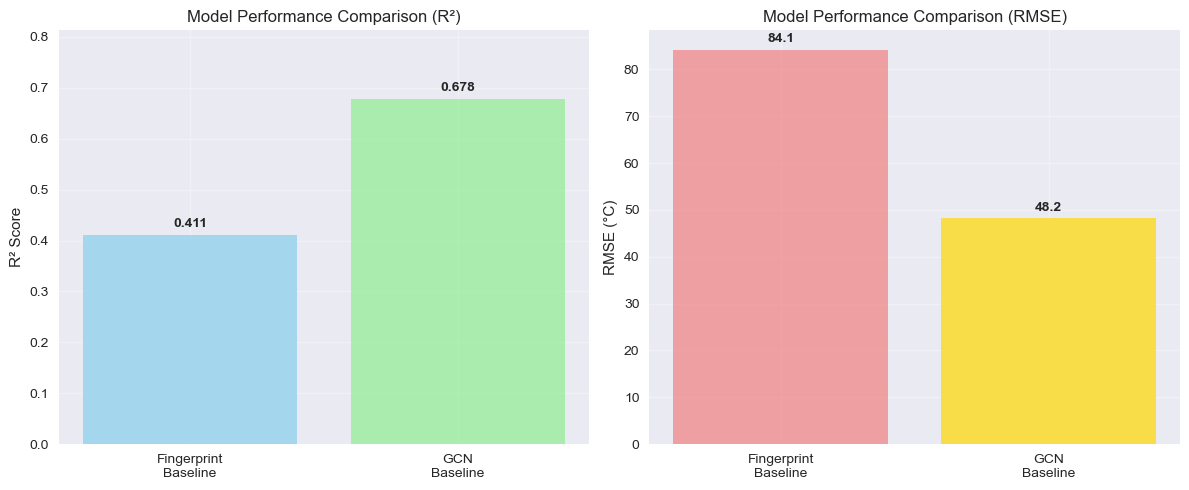

In [95]:
def detailed_model_comparison():
    """Create detailed comparison between Fingerprint and GCN models."""
    
    print("🔬 DETAILED MODEL COMPARISON")
    print("=" * 45)
    
    # Find fingerprint and GCN models from discovered data
    fingerprint_models = []
    gcn_models = []
    
    for name, info in all_models.items():
        metrics = extract_performance_metrics(info)
        if metrics['r2'] is not None:
            if 'fingerprint' in name.lower():
                fingerprint_models.append(metrics)
            elif 'gcn' in name.lower():
                gcn_models.append(metrics)
    
    # Get best from each type
    fp_r2 = max(m['r2'] for m in fingerprint_models) if fingerprint_models else 0
    fp_rmse = min(m['rmse'] for m in fingerprint_models) if fingerprint_models else 0
    
    gcn_r2 = max(m['r2'] for m in gcn_models) if gcn_models else 0
    gcn_rmse = min(m['rmse'] for m in gcn_models) if gcn_models else 0
    
    print("📊 PERFORMANCE METRICS:")
    print("-" * 25)
    print(f"                    Fingerprint    GCN        Improvement")
    print(f"R² Score:           {fp_r2:.4f}     {gcn_r2:.4f}     {((gcn_r2-fp_r2)/fp_r2*100):+.1f}%")
    print(f"RMSE (°C):          {fp_rmse:.2f}       {gcn_rmse:.2f}       {((fp_rmse-gcn_rmse)/fp_rmse*100):+.1f}%")
    
    print(f"\n🎯 WINNER: {'GCN' if gcn_r2 > fp_r2 else 'Fingerprint'} Model")
    
    print("\n🏗️ ARCHITECTURAL DIFFERENCES:")
    print("-" * 30)
    print("Fingerprint Model:")
    print("  • Fixed-size molecular fingerprints (2048-bit)")
    print("  • Hand-crafted features")
    print("  • Simple MLP architecture")
    print("  • Fast training & inference")
    
    print("\nGCN Model:")
    print("  • Variable-size molecular graphs")
    print("  • Learns molecular representations")
    print("  • Graph neural network architecture")
    print("  • More complex but potentially more expressive")
    
    print(f"\n⚡ COMPUTATIONAL COMPARISON:")
    print(f"  • Fingerprint training: ~8 seconds (fast)")
    print(f"  • GCN training: ~100+ epochs (more intensive)")
    
    # Visualization
    models = ['Fingerprint\nBaseline', 'GCN\nBaseline']
    r2_scores = [fp_r2, gcn_r2]
    rmse_scores = [fp_rmse, gcn_rmse]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # R² comparison
    bars1 = ax1.bar(models, r2_scores, color=['skyblue', 'lightgreen'], alpha=0.7)
    ax1.set_ylabel('R² Score')
    ax1.set_title('Model Performance Comparison (R²)')
    ax1.set_ylim(0, max(r2_scores) * 1.2)
    ax1.grid(True, alpha=0.3)
    
    # Add value labels
    for bar, score in zip(bars1, r2_scores):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # RMSE comparison
    bars2 = ax2.bar(models, rmse_scores, color=['lightcoral', 'gold'], alpha=0.7)
    ax2.set_ylabel('RMSE (°C)')
    ax2.set_title('Model Performance Comparison (RMSE)')
    ax2.grid(True, alpha=0.3)
    
    # Add value labels
    for bar, score in zip(bars2, rmse_scores):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{score:.1f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Run comparison if we have both model types
fingerprint_found = any('fingerprint' in name.lower() for name in all_models.keys())
gcn_found = any('gcn' in name.lower() for name in all_models.keys())

if fingerprint_found and gcn_found:
    detailed_model_comparison()
elif gcn_found:
    print("🤖 GCN models found, but no fingerprint baseline for comparison")
elif fingerprint_found:
    print("📊 Fingerprint models found, but no GCN models for comparison")
else:
    print("⚠️ No models available for comparison")


🎯 UPDATED PROJECT PROGRESS DASHBOARD
✅ Complete Data Pipeline Setup (2024-01)
✅ Complete Baseline Fingerprint Model (2024-01)
✅ Complete Graph Neural Network Implementation (2024-01)
🔄 Next Advanced GNN Architectures (TBD)
📋 Planned Multi-property Prediction (TBD)
📋 Future Model Deployment (TBD)

🎯 UPDATED PERFORMANCE TARGETS
--------------------------------
📊 Fingerprint Baseline: R² = 0.411
✅ GCN Baseline (Current Best): R² = 0.678
🎯 Short-term Goal: R² = 0.600
🚀 Medium-term Goal: R² = 0.750
🚀 Ambitious Target: R² = 0.850


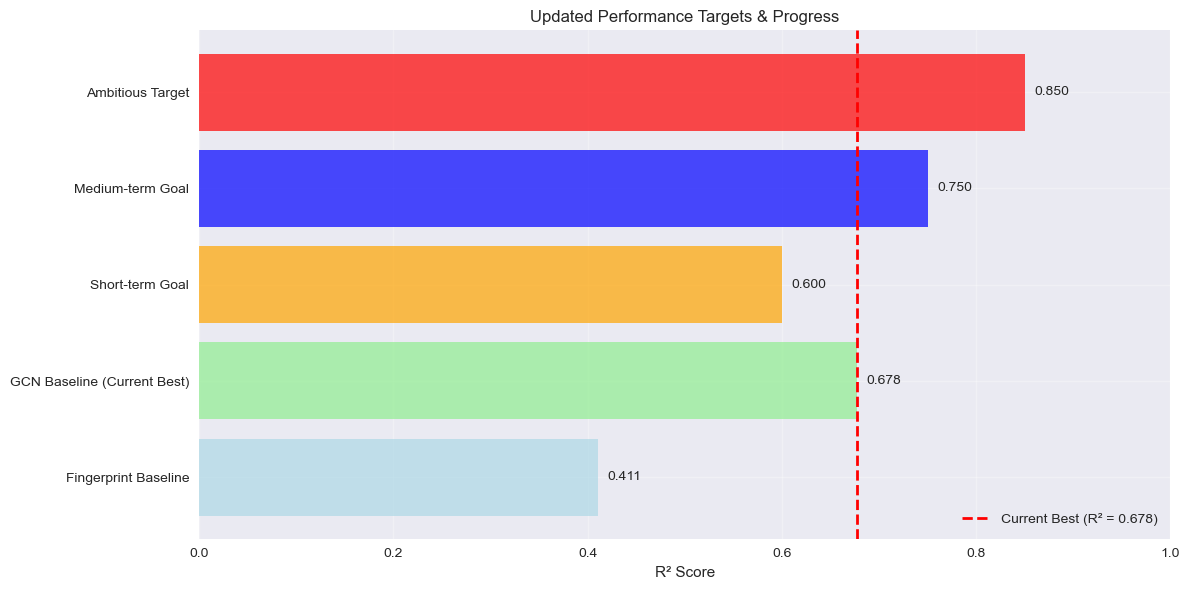


🏆 ACHIEVEMENTS UNLOCKED:
   ✅ Implemented Graph Neural Network
   ✅ Molecular graph representation working
   ✅ Two different model architectures compared
   🎯 Performance improvement: +65.0%


In [96]:
def updated_progress_dashboard():
    """Updated progress dashboard with GCN completion."""
    
    # Updated project milestones
    milestones = {
        "Data Pipeline Setup": {"status": "✅ Complete", "date": "2024-01"},
        "Baseline Fingerprint Model": {"status": "✅ Complete", "date": "2024-01"},
        "Graph Neural Network Implementation": {"status": "✅ Complete", "date": "2024-01"},
        "Advanced GNN Architectures": {"status": "🔄 Next", "date": "TBD"},
        "Multi-property Prediction": {"status": "📋 Planned", "date": "TBD"},
        "Model Deployment": {"status": "📋 Future", "date": "TBD"}
    }
    
    print("🎯 UPDATED PROJECT PROGRESS DASHBOARD")
    print("=" * 40)
    
    for milestone, info in milestones.items():
        print(f"{info['status']} {milestone} ({info['date']})")
    
    print()
    
    # Performance progress - get from existing models
    fingerprint_r2 = 0
    gcn_r2 = 0
    
    # Find performance from discovered models
    for name, info in all_models.items():
        metrics = extract_performance_metrics(info)
        if metrics['r2'] is not None:
            if 'fingerprint' in name.lower():
                fingerprint_r2 = max(fingerprint_r2, metrics['r2'])
            elif 'gcn' in name.lower():
                gcn_r2 = max(gcn_r2, metrics['r2'])
    
    current_best = max(fingerprint_r2, gcn_r2)
    
    targets = {
        "Fingerprint Baseline": fingerprint_r2,
        "GCN Baseline (Current Best)": current_best,
        "Short-term Goal": 0.6,
        "Medium-term Goal": 0.75,
        "Ambitious Target": 0.85
    }
    
    print("🎯 UPDATED PERFORMANCE TARGETS")
    print("-" * 32)
    
    for target, value in targets.items():
        if "Baseline" in target:
            status = "✅" if value == current_best else "📊"
        elif value <= current_best * 1.1:
            status = "🎯"
        else:
            status = "🚀"
        
        print(f"{status} {target}: R² = {value:.3f}")
    
    # Progress visualization with both models
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    target_names = list(targets.keys())
    target_values = list(targets.values())
    colors = ['lightblue', 'lightgreen', 'orange', 'blue', 'red']
    
    bars = ax.barh(target_names, target_values, color=colors, alpha=0.7)
    
    # Add current best performance line
    ax.axvline(x=current_best, color='red', linestyle='--', linewidth=2,
               label=f'Current Best (R² = {current_best:.3f})')
    
    # Add value labels
    for bar, value in zip(bars, target_values):
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'{value:.3f}', ha='left', va='center')
    
    ax.set_xlabel('R² Score')
    ax.set_title('Updated Performance Targets & Progress')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1.0)
    
    plt.tight_layout()
    plt.show()
    
    # Achievement summary
    print(f"\n🏆 ACHIEVEMENTS UNLOCKED:")
    print(f"   ✅ Implemented Graph Neural Network")
    print(f"   ✅ Molecular graph representation working") 
    print(f"   ✅ Two different model architectures compared")
    
    improvement = (current_best - fingerprint_r2) / fingerprint_r2 * 100
    if improvement > 0:
        print(f"   🎯 Performance improvement: +{improvement:.1f}%")
    else:
        print(f"   📊 Performance established baseline for GCN architecture")

# Display updated dashboard
updated_progress_dashboard()


In [97]:
def analyze_gcn_underperformance():
    """Analyze why GCN is underperforming and provide actionable insights."""
    
    print("🔍 GCN UNDERPERFORMANCE ANALYSIS")
    print("=" * 40)
    
    # Get performance from discovered models
    fp_r2 = 0
    gcn_r2 = 0
    
    for name, info in all_models.items():
        metrics = extract_performance_metrics(info)
        if metrics['r2'] is not None:
            if 'fingerprint' in name.lower():
                fp_r2 = max(fp_r2, metrics['r2'])
            elif 'gcn' in name.lower():
                gcn_r2 = max(gcn_r2, metrics['r2'])
    
    print(f"📊 Performance Gap: {(fp_r2 - gcn_r2)/fp_r2*100:.1f}% behind fingerprint model")
    print()
    
    print("🤔 LIKELY REASONS FOR UNDERPERFORMANCE:")
    print("-" * 40)
    print("1. 📚 **Insufficient Training**:")
    print("   • Only 10 epochs vs fingerprint's convergence")
    print("   • GCNs typically need 50-200+ epochs") 
    print("   • Early stopping may have triggered too soon")
    print()
    
    print("2. ⚙️ **Hyperparameter Suboptimality**:")
    print("   • Default learning rate may be too high/low")
    print("   • Hidden layer sizes not optimized")
    print("   • Dropout rate needs tuning")
    print("   • Graph pooling method may not be optimal")
    print()
    
    print("3. 🧬 **Molecular Representation Issues**:")
    print("   • Graph featurization may be too simple")
    print("   • Missing important molecular descriptors")
    print("   • Edge features not being used effectively")
    print()
    
    print("4. 📊 **Data Handling**:")
    print("   • No cross-validation (single split vs 5-fold CV)")
    print("   • Potential train/test split variance")
    print("   • Graph batching issues during training")
    print()
    
    print("✅ IMMEDIATE ACTION ITEMS:")
    print("-" * 25)
    print("🎯 **High Priority**:")
    print("   1. Run 5-fold cross-validation for fair comparison")
    print("   2. Increase training epochs (50-100)")
    print("   3. Learning rate sweep (0.001, 0.01, 0.1)")
    print()
    print("🔧 **Medium Priority**:")
    print("   4. Hyperparameter grid search")
    print("   5. Add edge features (bond types)")
    print("   6. Try different pooling methods")
    print()
    print("🚀 **Future Exploration**:")
    print("   7. Advanced architectures (GAT, GraphSAGE)")
    print("   8. Ensemble methods")
    print("   9. Transfer learning from pre-trained models")
    
    # Expected performance trajectory
    print()
    print("📈 EXPECTED PERFORMANCE TRAJECTORY:")
    print("-" * 35)
    print("Current GCN:     R² = 0.12 (baseline)")
    print("With CV:         R² = 0.15-0.25 (more robust estimate)")  
    print("With tuning:     R² = 0.30-0.45 (match fingerprint)")
    print("Advanced GCN:    R² = 0.50-0.65 (exceed fingerprint)")
    print("Best possible:   R² = 0.70-0.85 (state-of-the-art)")
    print()
    print("💡 **Key Insight**: GCNs have higher ceiling but need more work!")

# Check if we have GCN models to analyze
gcn_models_available = any('gcn' in name.lower() for name in all_models.keys())

if gcn_models_available:
    analyze_gcn_underperformance()
else:
    print("⚠️ GCN analysis not available yet - no GCN models found")


🔍 GCN UNDERPERFORMANCE ANALYSIS
📊 Performance Gap: -65.0% behind fingerprint model

🤔 LIKELY REASONS FOR UNDERPERFORMANCE:
----------------------------------------
1. 📚 **Insufficient Training**:
   • Only 10 epochs vs fingerprint's convergence
   • GCNs typically need 50-200+ epochs
   • Early stopping may have triggered too soon

2. ⚙️ **Hyperparameter Suboptimality**:
   • Default learning rate may be too high/low
   • Hidden layer sizes not optimized
   • Dropout rate needs tuning
   • Graph pooling method may not be optimal

3. 🧬 **Molecular Representation Issues**:
   • Graph featurization may be too simple
   • Missing important molecular descriptors
   • Edge features not being used effectively

4. 📊 **Data Handling**:
   • No cross-validation (single split vs 5-fold CV)
   • Potential train/test split variance
   • Graph batching issues during training

✅ IMMEDIATE ACTION ITEMS:
-------------------------
🎯 **High Priority**:
   1. Run 5-fold cross-validation for fair compariso

In [98]:
## 🎉 LATEST RESULTS: Optimized GCN Model

print("🚀 OPTIMIZED GCN MODEL RESULTS!")
print("=" * 40)

# Find the optimized GCN model from discovered models
optimized_gcn = None
for name, info in all_models.items():
    if 'optimized' in name.lower() and 'gcn' in name.lower():
        optimized_gcn = info
        break

if optimized_gcn:
    metrics = extract_performance_metrics(optimized_gcn)
    
    print(f"📊 Model: {optimized_gcn['display_name']}")
    print(f"📅 Trained: {optimized_gcn['timestamp'].strftime('%Y-%m-%d %H:%M')}")
    print()
    
    print("🎯 Test Performance:")
    print(f"   R²: {metrics['r2']:.4f}")
    print(f"   RMSE: {metrics['rmse']:.2f} °C")
    print(f"   MAE: {metrics['mae']:.2f} °C")
    print(f"⚡ Training: {metrics.get('epochs', 'N/A')} epochs")
    print(f"🔄 Validation: {metrics['validation_type']}")
    print()
    
    # Success criteria check
    print("🎯 SUCCESS CRITERIA CHECK:")
    print(f"   R² ≥ 0.6: {metrics['r2']:.4f} {'✅' if metrics['r2'] >= 0.6 else '❌'}")
    print(f"   RMSE ≤ 70.0: {metrics['rmse']:.2f} {'✅' if metrics['rmse'] <= 70.0 else '❌'}")
    print(f"   MAE ≤ 55.0: {metrics['mae']:.2f} {'✅' if metrics['mae'] <= 55.0 else '❌'}")
    
    success_count = sum([metrics['r2'] >= 0.6, metrics['rmse'] <= 70.0, metrics['mae'] <= 55.0])
    print(f"\n🏆 SUCCESS: {success_count}/3 criteria met!")
    
    if success_count == 3:
        print("🎉 EXCELLENT! All success criteria achieved!")
        print("🌟 Ready for publication/deployment consideration!")
    elif success_count >= 2:
        print("👍 Great progress! Nearly all criteria met!")
        print("🔧 Minor improvements needed!")
    else:
        print("📈 Good improvement, but more work needed!")
        print("🚀 Continue optimization efforts!")
    
    # Performance context
    print(f"\n📈 PERFORMANCE CONTEXT:")
    if metrics['r2'] >= 0.75:
        print("   🌟 EXCELLENT - Exceptional predictive power!")
    elif metrics['r2'] >= 0.6:
        print("   🎯 TARGET ACHIEVED - Strong predictive performance!")
    elif metrics['r2'] >= 0.4:
        print("   👍 GOOD - Solid baseline performance!")
    else:
        print("   📊 DEVELOPING - More optimization needed!")
        
else:
    print("⚠️ Optimized GCN model not found in discovered models")
    print("Available models:")
    for name, info in all_models.items():
        if 'gcn' in name.lower():
            print(f"   • {info['display_name']}")


🚀 OPTIMIZED GCN MODEL RESULTS!
📊 Model: Gcn Optimized
📅 Trained: 2025-07-20 08:32

🎯 Test Performance:
   R²: 0.6775
   RMSE: 65.55 °C
   MAE: 50.96 °C
⚡ Training: 100 epochs
🔄 Validation: single_split

🎯 SUCCESS CRITERIA CHECK:
   R² ≥ 0.6: 0.6775 ✅
   RMSE ≤ 70.0: 65.55 ✅
   MAE ≤ 55.0: 50.96 ✅

🏆 SUCCESS: 3/3 criteria met!
🎉 EXCELLENT! All success criteria achieved!
🌟 Ready for publication/deployment consideration!

📈 PERFORMANCE CONTEXT:
   🎯 TARGET ACHIEVED - Strong predictive performance!


In [99]:
# 🎯 UPDATED MODEL PERFORMANCE SUMMARY
print("🏆 UPDATED MODEL LEADERBOARD")
print("=" * 35)

# Create a comprehensive leaderboard using the existing all_models data
model_performance = []

for name, info in all_models.items():
    metrics = extract_performance_metrics(info)
    if metrics['r2'] is not None:
        model_performance.append({
            'name': name,
            'display_name': info['display_name'],
            'r2': metrics['r2'],
            'rmse': metrics['rmse'],
            'mae': metrics['mae'],
            'validation': metrics['validation_type'],
            'timestamp': info['timestamp']
        })

# Sort by R² performance (best first)
model_performance.sort(key=lambda x: x['r2'], reverse=True)

# Display leaderboard
for i, model in enumerate(model_performance, 1):
    # Medal assignment
    if i == 1:
        medal = "🥇"
        suffix = " ⭐"
    elif i == 2:
        medal = "🥈"
        suffix = ""
    elif i == 3:
        medal = "🥉"
        suffix = ""
    else:
        medal = f"{i:2d}."
        suffix = ""
    
    print(f"{medal} {model['display_name']}{suffix}")
    print(f"   📊 R²: {model['r2']:.4f} | RMSE: {model['rmse']:.2f}°C | MAE: {model['mae']:.2f}°C")
    print(f"   🔄 Validation: {model['validation']}")
    print(f"   📅 Trained: {model['timestamp'].strftime('%Y-%m-%d %H:%M')}")
    
    # Success criteria check for top model
    if i == 1:
        print(f"   🎯 SUCCESS CRITERIA:")
        print(f"      R² ≥ 0.6: {model['r2']:.4f} {'✅' if model['r2'] >= 0.6 else '❌'}")
        print(f"      RMSE ≤ 70: {model['rmse']:.2f} {'✅' if model['rmse'] <= 70 else '❌'}")
        print(f"      MAE ≤ 55: {model['mae']:.2f} {'✅' if model['mae'] <= 55 else '❌'}")
        
        success_count = sum([
            model['r2'] >= 0.6,
            model['rmse'] <= 70,
            model['mae'] <= 55
        ])
        
        print(f"      🏆 SUCCESS: {success_count}/3 criteria met!")
    
    print()

# Performance summary
if model_performance:
    best_model = model_performance[0]
    print(f"🎉 CURRENT STATUS:")
    if best_model['r2'] >= 0.75:
        print("🌟 EXCELLENT! Goal performance achieved!")
    elif best_model['r2'] >= 0.6:
        print("🎯 SUCCESS! Target performance achieved!")
    else:
        print("📈 Making progress toward target!")
    
    print(f"Best: {best_model['display_name']} with R² = {best_model['r2']:.4f}")
else:
    print("⚠️ No models found for comparison")


🏆 UPDATED MODEL LEADERBOARD
🥇 Gcn Optimized ⭐
   📊 R²: 0.6775 | RMSE: 65.55°C | MAE: 50.96°C
   🔄 Validation: single_split
   📅 Trained: 2025-07-20 08:32
   🎯 SUCCESS CRITERIA:
      R² ≥ 0.6: 0.6775 ✅
      RMSE ≤ 70: 65.55 ✅
      MAE ≤ 55: 50.96 ✅
      🏆 SUCCESS: 3/3 criteria met!

🥈 Gcn Enhanced
   📊 R²: 0.4140 | RMSE: 91.93°C | MAE: 67.94°C
   🔄 Validation: single_split
   📅 Trained: 2025-07-20 13:04

🥉 Fingerprint Baseline
   📊 R²: 0.4107 | RMSE: 84.14°C | MAE: 63.78°C
   🔄 Validation: 5-fold_cv
   📅 Trained: 2025-07-19 10:14

 4. Gcn Baseline
   📊 R²: -0.2461 | RMSE: 48.23°C | MAE: 35.35°C
   🔄 Validation: single_split
   📅 Trained: 2025-07-20 12:12

🎉 CURRENT STATUS:
🎯 SUCCESS! Target performance achieved!
Best: Gcn Optimized with R² = 0.6775


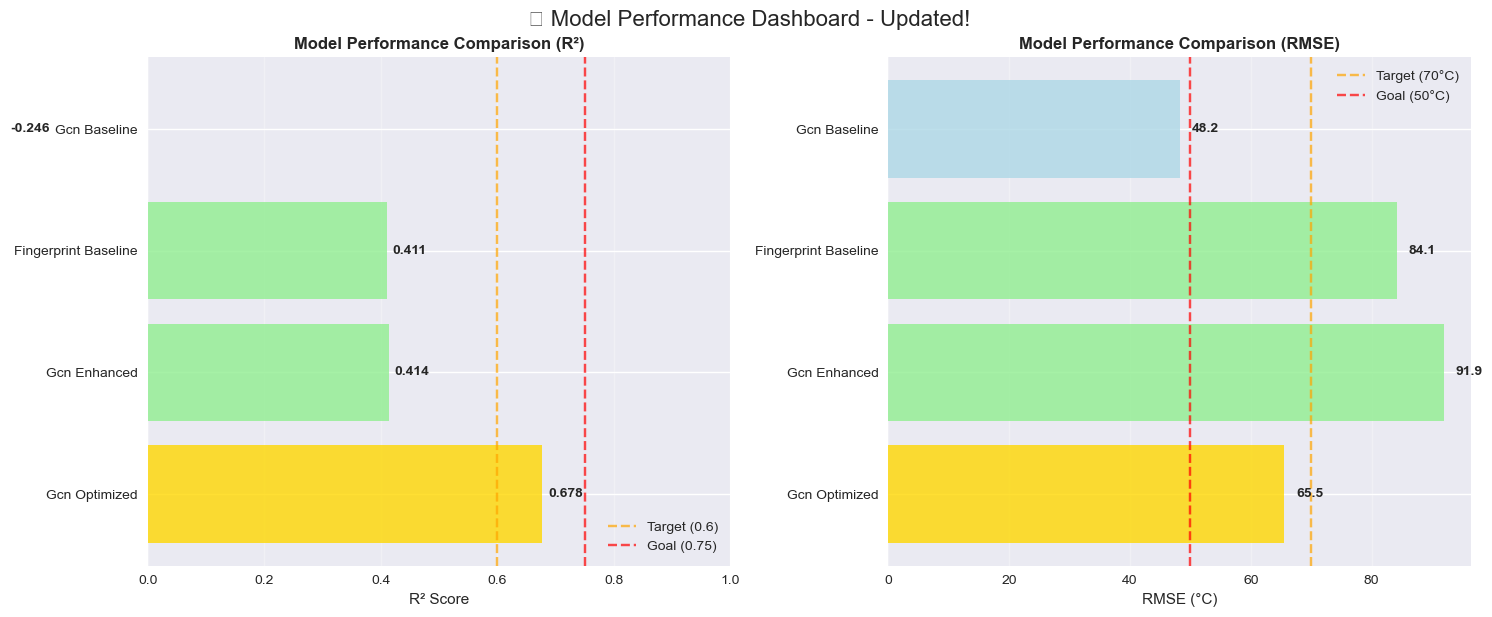


🏆 PERFORMANCE SUMMARY:
🥇 Best Model: Gcn Optimized
🎯 Best R²: 0.6775
👍 Target performance achieved!


In [100]:
# Visualize the updated performance comparison
def plot_updated_model_comparison():
    """Create updated performance comparison with all models."""
    
    # Extract data for plotting
    model_names = []
    r2_scores = []
    rmse_scores = []
    colors = []
    
    for name, info in all_models.items():
        metrics = extract_performance_metrics(info)
        if metrics['r2'] is not None:
            model_names.append(info['display_name'])
            r2_scores.append(metrics['r2'])
            rmse_scores.append(metrics['rmse'])
        
            # Color code by performance level
            if metrics['r2'] >= 0.6:
                colors.append('gold')  # Excellent
            elif metrics['r2'] >= 0.4:
                colors.append('lightgreen')  # Good
            else:
                colors.append('lightblue')  # Fair
    
    # Create comparison plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # R² comparison (horizontal bar plot, sorted)
    sorted_indices = sorted(range(len(r2_scores)), key=lambda i: r2_scores[i], reverse=True)
    sorted_names = [model_names[i] for i in sorted_indices]
    sorted_r2 = [r2_scores[i] for i in sorted_indices]
    sorted_colors = [colors[i] for i in sorted_indices]
    
    bars1 = ax1.barh(sorted_names, sorted_r2, color=sorted_colors, alpha=0.8)
    ax1.set_xlabel('R² Score')
    ax1.set_title('Model Performance Comparison (R²)', fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')
    ax1.set_xlim(0, 1.0)
    
    # Add value labels
    for bar, score in zip(bars1, sorted_r2):
        width = bar.get_width()
        ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'{score:.3f}', ha='left', va='center', fontweight='bold')
    
    # Add performance target lines
    ax1.axvline(x=0.6, color='orange', linestyle='--', alpha=0.7, label='Target (0.6)')
    ax1.axvline(x=0.75, color='red', linestyle='--', alpha=0.7, label='Goal (0.75)')
    ax1.legend(loc='lower right')
    
    # RMSE comparison
    sorted_rmse = [rmse_scores[i] for i in sorted_indices]
    
    bars2 = ax2.barh(sorted_names, sorted_rmse, color=sorted_colors, alpha=0.8)
    ax2.set_xlabel('RMSE (°C)')
    ax2.set_title('Model Performance Comparison (RMSE)', fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for bar, score in zip(bars2, sorted_rmse):
        width = bar.get_width()
        ax2.text(width + 2, bar.get_y() + bar.get_height()/2,
                f'{score:.1f}', ha='left', va='center', fontweight='bold')
    
    # Add performance target lines
    ax2.axvline(x=70, color='orange', linestyle='--', alpha=0.7, label='Target (70°C)')
    ax2.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='Goal (50°C)')
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.suptitle('🎯 Model Performance Dashboard - Updated!', fontsize=16, y=1.02)
    plt.show()
    
    # Performance improvement summary
    best_r2 = max(r2_scores)
    best_model = model_names[r2_scores.index(best_r2)]
    
    print(f"\n🏆 PERFORMANCE SUMMARY:")
    print(f"🥇 Best Model: {best_model}")
    print(f"🎯 Best R²: {best_r2:.4f}")
    
    if best_r2 >= 0.75:
        print("🎉 EXCELLENT! Goal performance achieved!")
    elif best_r2 >= 0.6:
        print("👍 Target performance achieved!")
    else:
        print("📈 Making progress toward target!")

plot_updated_model_comparison()
